In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : "#F8F9FA",
    "axes.titlesize"   : 14,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 12,
    "xtick.labelsize"  : 11,
    "ytick.labelsize"  : 11,
    "legend.fontsize"  : 10,
    "font.family"      : "DejaVu Sans",
})
BLUE = "#66b3ff"
RED  = "#ff6666"
PAL  = {"No": BLUE, "Yes": RED}

In [3]:
print("=" * 55)
print("  SECTION 1 — DATA LOADING")
print("=" * 55)
 
df = pd.read_csv("Customer Churn.csv")
 
print(f"\n✔  Shape          : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"✔  Columns        : {list(df.columns)}")
print(f"\n--- First 5 Rows ---")
print(df.head())
print(f"\n--- Data Types ---")
print(df.dtypes)

  SECTION 1 — DATA LOADING

✔  Shape          : 7,043 rows × 21 columns
✔  Columns        : ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

--- First 5 Rows ---
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No

In [4]:
print("\n" + "=" * 55)
print("  SECTION 2 — DATA PRE-PROCESSING")
print("=" * 55)


  SECTION 2 — DATA PRE-PROCESSING


In [5]:
# Fix TotalCharges
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
missing = df["TotalCharges"].isnull().sum()
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)
print(f"\n✔  TotalCharges null values fixed  : {missing}")
 
# Binary encode Churn
df["Churn_Flag"] = np.where(df["Churn"] == "Yes", 1, 0)
print(f"✔  Churn_Flag encoded              : Yes=1 / No=0")


✔  TotalCharges null values fixed  : 11
✔  Churn_Flag encoded              : Yes=1 / No=0


In [6]:
# Tenure segments
bins   = [0, 6, 12, 24, 48, 72]
labels = ["0–6 mo", "7–12 mo", "13–24 mo", "25–48 mo", "49–72 mo"]
df["TenureGroup"] = pd.cut(df["tenure"], bins=bins, labels=labels)
print(f"✔  TenureGroup engineered          : {labels}")

✔  TenureGroup engineered          : ['0–6 mo', '7–12 mo', '13–24 mo', '25–48 mo', '49–72 mo']


In [7]:
# Summary stats
print(f"\n--- Descriptive Statistics ---")
print(df[["tenure", "MonthlyCharges", "TotalCharges"]].describe().round(2))
 
print(f"\n--- Missing Values ---")
print(df.isnull().sum()[df.isnull().sum() > 0])
 
print(f"\n--- Churn Distribution ---")
print(df["Churn"].value_counts())
print(f"\nOverall Churn Rate : {df['Churn_Flag'].mean()*100:.1f}%")


--- Descriptive Statistics ---
        tenure  MonthlyCharges  TotalCharges
count  7043.00         7043.00       7043.00
mean     32.37           64.76       2281.92
std      24.56           30.09       2265.27
min       0.00           18.25         18.80
25%       9.00           35.50        402.22
50%      29.00           70.35       1397.48
75%      55.00           89.85       3786.60
max      72.00          118.75       8684.80

--- Missing Values ---
TenureGroup    11
dtype: int64

--- Churn Distribution ---
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Overall Churn Rate : 26.5%


In [8]:
print("\n" + "=" * 55)
print("  SECTION 3 — DATA MODELING")
print("=" * 55)
 
churned     = df[df["Churn"] == "Yes"]
not_churned = df[df["Churn"] == "No"]
 
for feat in ["tenure", "MonthlyCharges", "TotalCharges"]:
    c  = churned[feat].dropna().values
    nc = not_churned[feat].dropna().values
    print(f"\n  {feat}")
    print(f"    Churned     → mean={np.mean(c):.1f}  median={np.median(c):.1f}  std={np.std(c):.1f}")
    print(f"    Not Churned → mean={np.mean(nc):.1f}  median={np.median(nc):.1f}  std={np.std(nc):.1f}")


  SECTION 3 — DATA MODELING

  tenure
    Churned     → mean=18.0  median=10.0  std=19.5
    Not Churned → mean=37.6  median=38.0  std=24.1

  MonthlyCharges
    Churned     → mean=74.4  median=79.7  std=24.7
    Not Churned → mean=61.3  median=64.4  std=31.1

  TotalCharges
    Churned     → mean=1531.8  median=703.5  std=1890.3
    Not Churned → mean=2552.9  median=1679.5  std=2327.4


In [9]:
print(f"\n  Key Churn Rates:")
print(f"    Month-to-month contract : {df[df['Contract']=='Month-to-month']['Churn_Flag'].mean()*100:.1f}%")
print(f"    Electronic check pay    : {df[df['PaymentMethod']=='Electronic check']['Churn_Flag'].mean()*100:.1f}%")
print(f"    Fiber optic internet    : {df[df['InternetService']=='Fiber optic']['Churn_Flag'].mean()*100:.1f}%")
print(f"    No Online Security      : {df[df['OnlineSecurity']=='No']['Churn_Flag'].mean()*100:.1f}%")
print(f"    Senior citizens         : {df[df['SeniorCitizen']==1]['Churn_Flag'].mean()*100:.1f}%")
print(f"    Tenure ≤ 6 months       : {df[df['tenure']<=6]['Churn_Flag'].mean()*100:.1f}%")


  Key Churn Rates:
    Month-to-month contract : 42.7%
    Electronic check pay    : 45.3%
    Fiber optic internet    : 41.9%
    No Online Security      : 41.8%
    Senior citizens         : 41.7%
    Tenure ≤ 6 months       : 52.9%


In [13]:
print("\n" + "=" * 55)
print("  SECTION 4 — DATA VISUALIZATION ")
print("=" * 55)


  SECTION 4 — DATA VISUALIZATION 



[1/11] Churn Distribution — Pie Chart


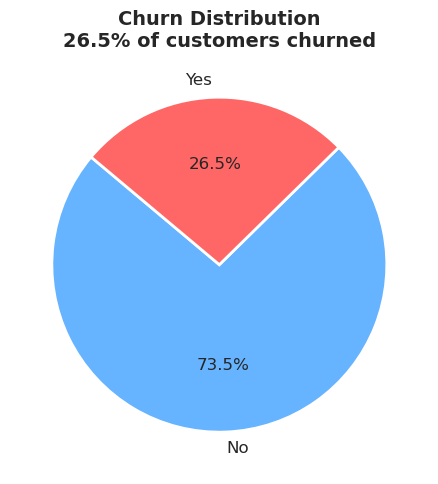

26.5% of customers churned. Gender is nearly 50/50.


In [11]:
print("\n[1/11] Churn Distribution — Pie Chart")
fig, ax = plt.subplots(figsize=(7, 5))
counts = df["Churn"].value_counts()
ax.pie(counts, labels=counts.index, autopct="%1.1f%%",
       colors=[BLUE, RED], startangle=140,
       wedgeprops=dict(edgecolor="white", linewidth=2),
       textprops={"fontsize": 12})
ax.set_title("Churn Distribution\n26.5% of customers churned", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
print("26.5% of customers churned. Gender is nearly 50/50.")


[2/11] Churn by Contract Type


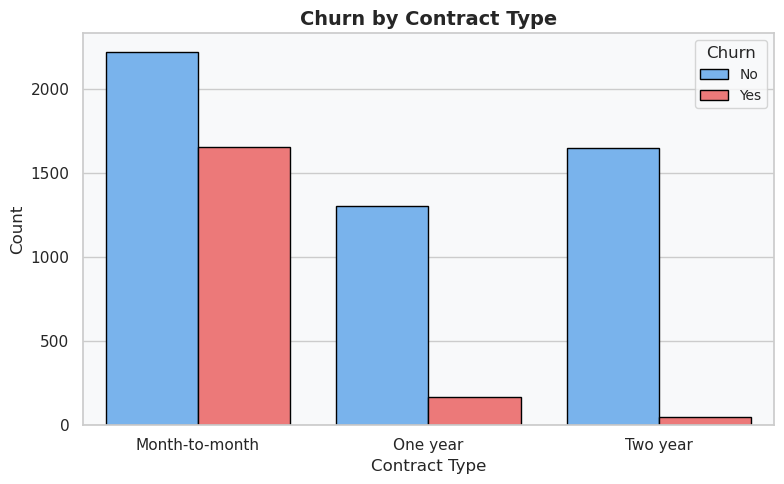


Month-to-month contracts have far higher churn than long-term contracts.


In [12]:
print("\n[2/11] Churn by Contract Type")
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x="Contract", hue="Churn",
              palette={"No": BLUE, "Yes": RED}, ax=ax, edgecolor="black")
ax.set_title("Churn by Contract Type", fontsize=14, fontweight="bold")
ax.set_xlabel("Contract Type", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()
print("\nMonth-to-month contracts have far higher churn than long-term contracts.")


[3/11] Churn by Internet Service


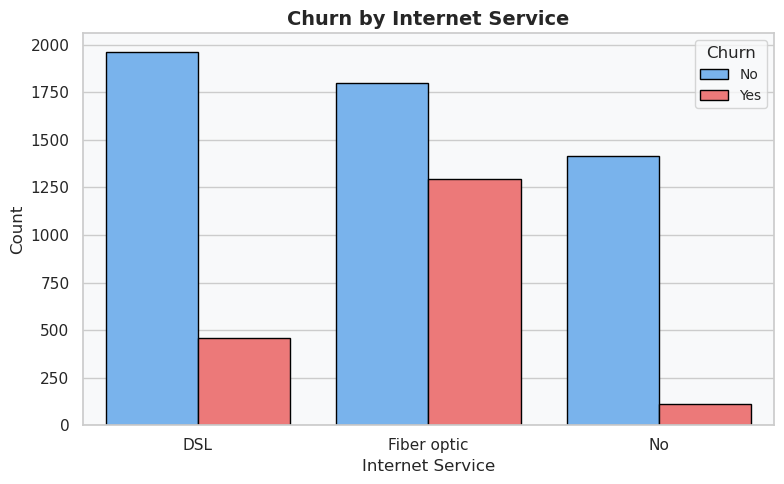


Fiber optic users churn at 41.9% — highest among all internet service types.


In [16]:
print("\n[3/11] Churn by Internet Service")
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x="InternetService", hue="Churn",
              palette={"No": BLUE, "Yes": RED}, ax=ax, edgecolor="black")
ax.set_title("Churn by Internet Service", fontsize=14, fontweight="bold")
ax.set_xlabel("Internet Service", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()
print("\nFiber optic users churn at 41.9% — highest among all internet service types.")


[4/11] Monthly Charges Distribution by Churn


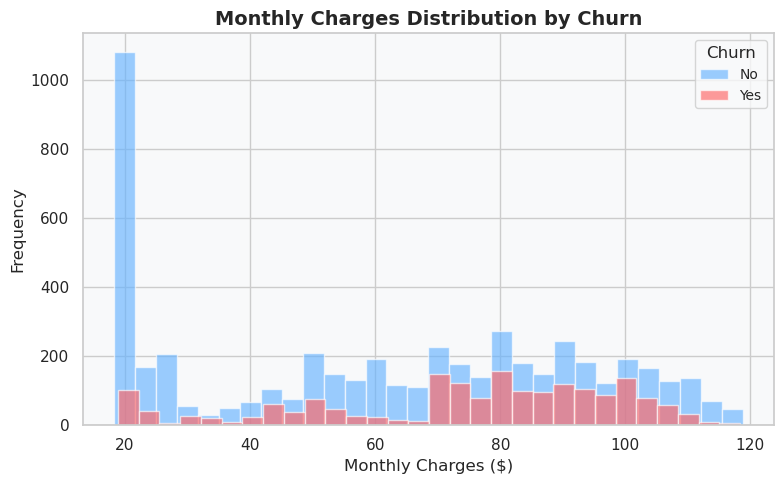


Churned customers tend to have higher monthly charges ($74 avg vs $61).


In [17]:
print("\n[4/11] Monthly Charges Distribution by Churn")
fig, ax = plt.subplots(figsize=(8, 5))
for label, grp in df.groupby("Churn"):
    ax.hist(grp["MonthlyCharges"], bins=30, alpha=0.65,
            color=PAL[label], label=label, edgecolor="white")
ax.set_title("Monthly Charges Distribution by Churn", fontsize=14, fontweight="bold")
ax.set_xlabel("Monthly Charges ($)", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.legend(title="Churn")
plt.tight_layout()
plt.show()
print("\nChurned customers tend to have higher monthly charges ($74 avg vs $61).")


[5/11] Tenure Distribution by Churn


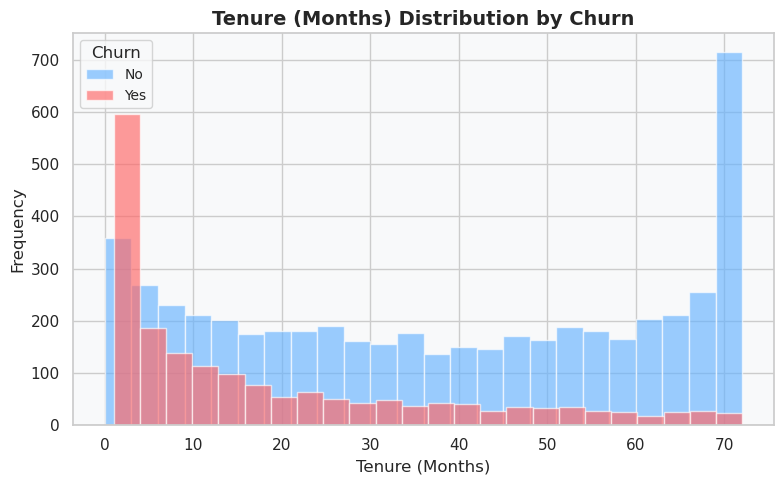


Churned customers have much shorter tenure — most leave within 6 months.


In [18]:
print("\n[5/11] Tenure Distribution by Churn")
fig, ax = plt.subplots(figsize=(8, 5))
for label, grp in df.groupby("Churn"):
    ax.hist(grp["tenure"], bins=24, alpha=0.65,
            color=PAL[label], label=label, edgecolor="white")
ax.set_title("Tenure (Months) Distribution by Churn", fontsize=14, fontweight="bold")
ax.set_xlabel("Tenure (Months)", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.legend(title="Churn")
plt.tight_layout()
plt.show()
print("\nChurned customers have much shorter tenure — most leave within 6 months.")


[6/11] Churn Rate by Payment Method


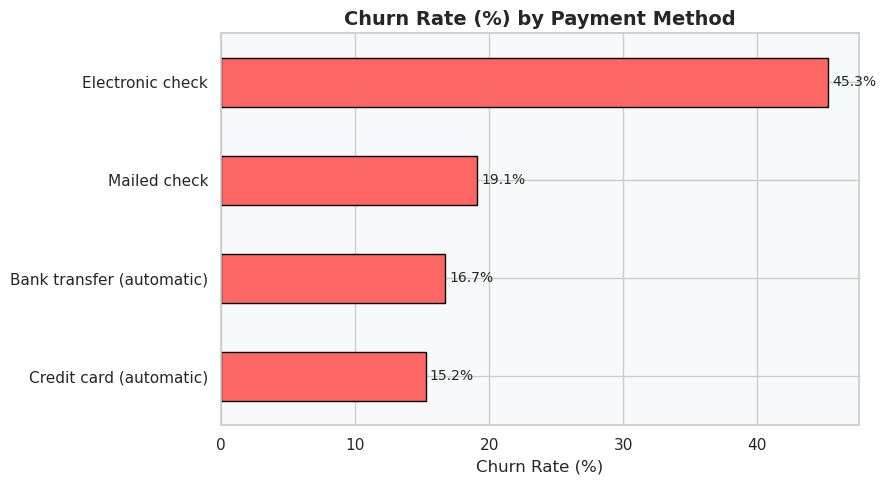


Electronic check users churn at 45.3% — highest payment method churn rate.


In [19]:
print("\n[6/11] Churn Rate by Payment Method")
pay = df.groupby(["PaymentMethod", "Churn"]).size().unstack(fill_value=0)
pay_pct = pay.div(pay.sum(axis=1), axis=0) * 100
fig, ax = plt.subplots(figsize=(9, 5))
pay_pct["Yes"].sort_values().plot(kind="barh", ax=ax, color=RED, edgecolor="black")
ax.set_title("Churn Rate (%) by Payment Method", fontsize=14, fontweight="bold")
ax.set_xlabel("Churn Rate (%)", fontsize=12)
ax.set_ylabel("")
for i, v in enumerate(pay_pct["Yes"].sort_values()):
    ax.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=10)
plt.tight_layout()
plt.show()
print("\nElectronic check users churn at 45.3% — highest payment method churn rate.")


[7/11] Churn Rate by Senior Citizen Status


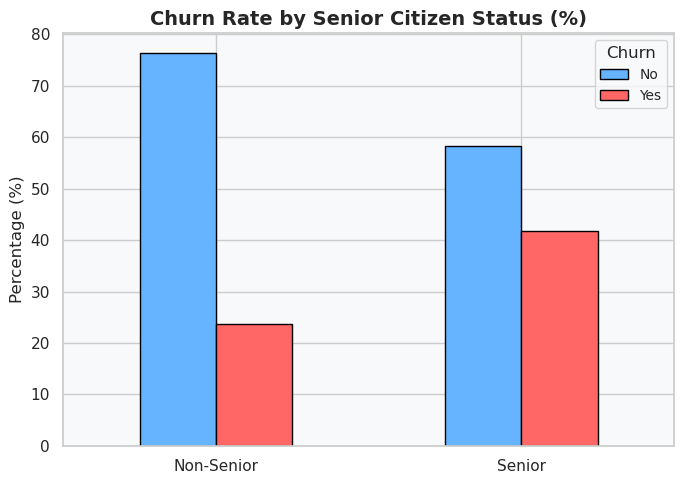


Senior citizens churn at 41.7% compared to 23.6% for non-seniors.


In [20]:
print("\n[7/11] Churn Rate by Senior Citizen Status")
fig, ax = plt.subplots(figsize=(7, 5))
senior = df.groupby(["SeniorCitizen", "Churn"]).size().unstack(fill_value=0)
senior.index = ["Non-Senior", "Senior"]
senior_pct = senior.div(senior.sum(axis=1), axis=0) * 100
senior_pct.plot(kind="bar", ax=ax, color=[BLUE, RED], edgecolor="black", width=0.5)
ax.set_title("Churn Rate by Senior Citizen Status (%)", fontsize=14, fontweight="bold")
ax.set_ylabel("Percentage (%)", fontsize=12)
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Churn")
plt.tight_layout()
plt.show()
print("\nSenior citizens churn at 41.7% compared to 23.6% for non-seniors.")


[8/11] Churn Rate Heatmap by Add-On Services


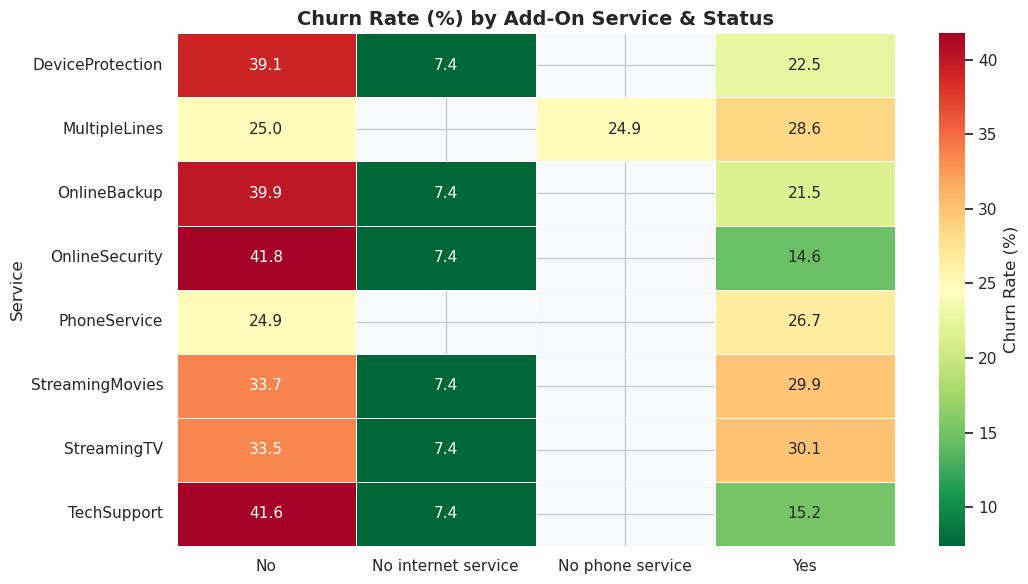


Customers without Online Security or Tech Support show the highest churn rates.


In [21]:
print("\n[8/11] Churn Rate Heatmap by Add-On Services")
service_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
                "TechSupport", "StreamingTV", "StreamingMovies",
                "MultipleLines", "PhoneService"]
rows_svc = []
for col in service_cols:
    for val in df[col].unique():
        rate = df[df[col] == val]["Churn_Flag"].mean() * 100
        rows_svc.append({"Service": col, "Value": val, "ChurnRate": rate})
svc_pivot = pd.DataFrame(rows_svc).pivot(index="Service", columns="Value", values="ChurnRate")
 
fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(svc_pivot, ax=ax, annot=True, fmt=".1f", cmap="RdYlGn_r",
            linewidths=0.5, annot_kws={"size": 11},
            cbar_kws={"label": "Churn Rate (%)"})
ax.set_title("Churn Rate (%) by Add-On Service & Status", fontsize=14, fontweight="bold")
ax.tick_params(axis="y", rotation=0)
ax.set_xlabel("")
plt.tight_layout()
plt.show()
print("\nCustomers without Online Security or Tech Support show the highest churn rates.")


[9/11] Scatter Plot — Tenure vs Monthly Charges


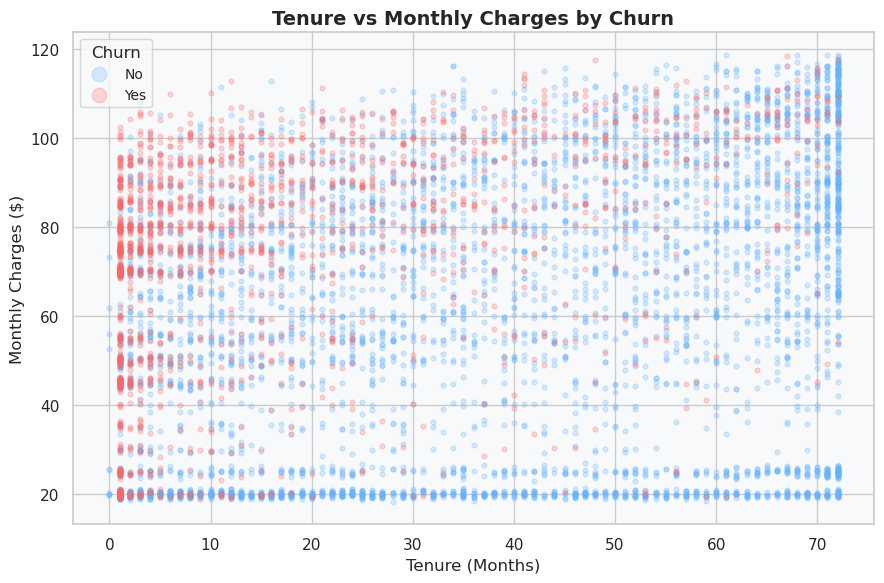


Churned customers cluster in low-tenure, high-charge zone — high-risk segment.


In [22]:
print("\n[9/11] Scatter Plot — Tenure vs Monthly Charges")
fig, ax = plt.subplots(figsize=(9, 6))
for label, grp in df.groupby("Churn"):
    ax.scatter(grp["tenure"], grp["MonthlyCharges"],
               alpha=0.25, s=12, color=PAL[label], label=label)
ax.set_title("Tenure vs Monthly Charges by Churn", fontsize=14, fontweight="bold")
ax.set_xlabel("Tenure (Months)", fontsize=12)
ax.set_ylabel("Monthly Charges ($)", fontsize=12)
ax.legend(title="Churn", markerscale=3)
plt.tight_layout()
plt.show()
print("\nChurned customers cluster in low-tenure, high-charge zone — high-risk segment.")


[10/11] Correlation Heatmap


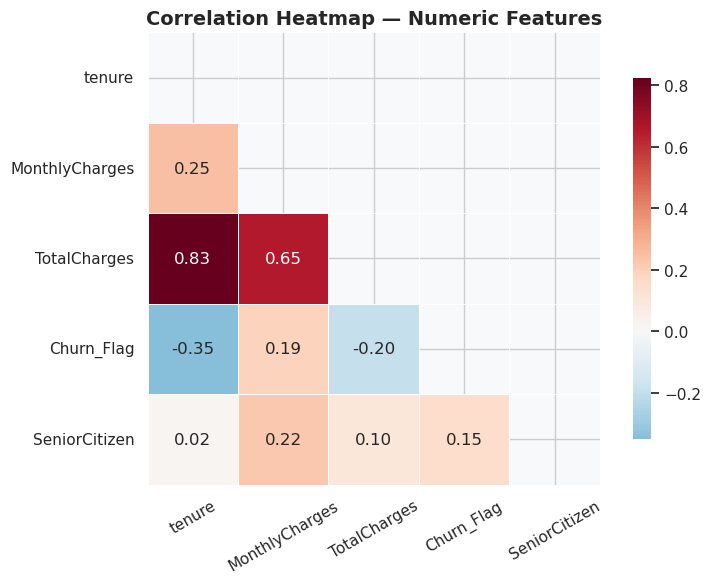


Tenure negatively correlates with churn (-0.35). Monthly charges positively correlate.


In [23]:
print("\n[10/11] Correlation Heatmap")
num_cols = ["tenure", "MonthlyCharges", "TotalCharges", "Churn_Flag", "SeniorCitizen"]
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, mask=mask, ax=ax, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, linewidths=0.5, square=True,
            annot_kws={"size": 12}, cbar_kws={"shrink": 0.8})
ax.set_title("Correlation Heatmap — Numeric Features", fontsize=14, fontweight="bold")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()
print("\nTenure negatively correlates with churn (-0.35). Monthly charges positively correlate.")


[11/11] Churn Rate & Customer Count by Tenure Segment


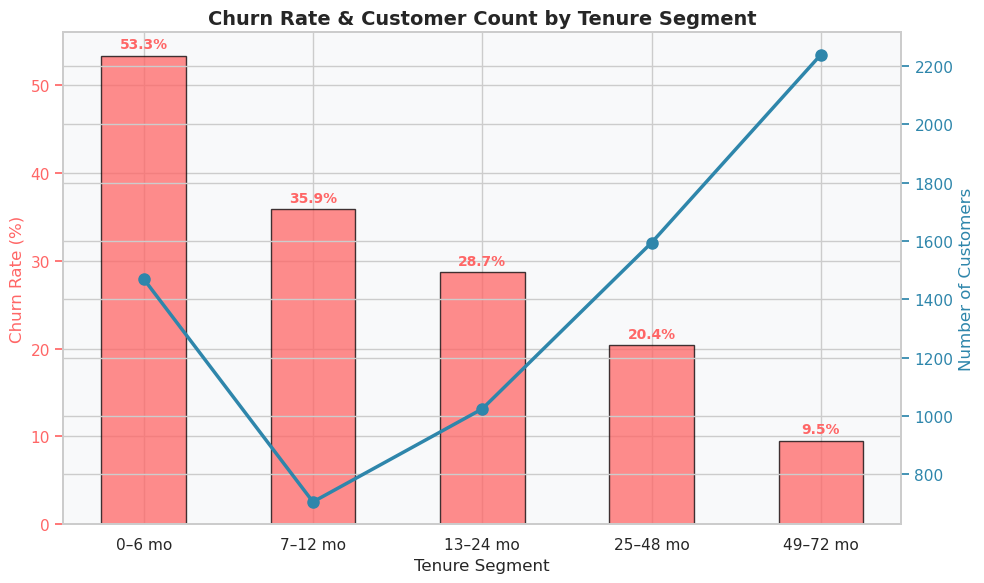


Customers with ≤6 months tenure churn at 52.9% — the highest risk group.


In [24]:
print("\n[11/11] Churn Rate & Customer Count by Tenure Segment")
seg = df.groupby("TenureGroup", observed=True)["Churn_Flag"].agg(["mean", "count"])
seg["mean"] *= 100
 
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()
bars = ax1.bar(seg.index, seg["mean"], color=RED, alpha=0.75, edgecolor="black", width=0.5)
ax2.plot(seg.index, seg["count"], color="#2E86AB", marker="o",
         linewidth=2.5, markersize=8, label="Customer Count")
ax1.set_title("Churn Rate & Customer Count by Tenure Segment", fontsize=14, fontweight="bold")
ax1.set_xlabel("Tenure Segment", fontsize=12)
ax1.set_ylabel("Churn Rate (%)", color=RED, fontsize=12)
ax2.set_ylabel("Number of Customers", color="#2E86AB", fontsize=12)
ax1.tick_params(axis="y", colors=RED)
ax2.tick_params(axis="y", colors="#2E86AB")
for bar, val in zip(bars, seg["mean"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{val:.1f}%", ha="center", va="bottom", fontsize=10, color=RED, fontweight="bold")
plt.tight_layout()
plt.show()
print("\nCustomers with ≤6 months tenure churn at 52.9% — the highest risk group.")

In [25]:
print("\n" + "=" * 55)
print("  ANALYSIS COMPLETE — KEY TAKEAWAYS")
print("=" * 55)
print("""
  1. Overall churn rate         : 26.5%
  2. Month-to-month contracts   : 42.7% churn (highest)
  3. Electronic check payment   : 45.3% churn
  4. Fiber optic internet       : 41.9% churn
  5. No Online Security         : 41.8% churn
  6. Senior citizens            : 41.7% churn
  7. Tenure ≤ 6 months          : 52.9% churn (critical!)
 
  Recommendation: Focus early retention efforts on
  new customers (≤6 months) on month-to-month plans
  paying by electronic check — highest churn risk group.
""")


  ANALYSIS COMPLETE — KEY TAKEAWAYS

  1. Overall churn rate         : 26.5%
  2. Month-to-month contracts   : 42.7% churn (highest)
  3. Electronic check payment   : 45.3% churn
  4. Fiber optic internet       : 41.9% churn
  5. No Online Security         : 41.8% churn
  6. Senior citizens            : 41.7% churn
  7. Tenure ≤ 6 months          : 52.9% churn (critical!)
 
  Recommendation: Focus early retention efforts on
  new customers (≤6 months) on month-to-month plans
  paying by electronic check — highest churn risk group.

